# Coding Session #5

---

## Today's session

Today's session is structured to teach more complex tasks in pandas and numpy. We will explore:

- Text cleaning
- Building functions in Python
- Quick summaries
- Intro to plotting (Seaborn)

### 0.1 Environment preparation

We begin by loading the libraries we’ll need. In Python, libraries are like toolkits: they extend the language with specialized functions.

- **pandas (pd)** is our main tool for working with tabular data. It introduces the DataFrame, which lets us manipulate datasets in a way that feels natural if you’ve used Excel or R.
- **NumPy (np)** provides the numerical backbone. It gives us arrays and fast mathematical functions, which pandas actually uses under the hood.
- **Seaborn (sns)** builds on top of Matplotlib to create a vast range of plots and visualization.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

# Show complete strings in pandas tables
pd.set_option("display.max_colwidth", None)


### 0.2 Reading Dataset


The **Database on Ideology, Money in Politics, and Elections (DIME), Version 4.0** provides a comprehensive record of campaign finance activity in the United States between **1979 and 2024**. It contains more than **850 million itemized contributions** from individuals and organizations to candidates, parties, and political committees at the federal, state, and local levels (Bonica, 2024).

DIME is organized into two primary components:

* **Candidate/Recipient Database** – includes information on candidates and committees, such as names, party affiliation, state, office sought, district, gender, incumbency status, fundraising totals, election outcomes, and multiple measures of ideology.
* **Contributor Database** – contains records on donors, both individuals and organizations, with demographic details, contribution histories, and ideological scores.

For this coding session, we use a **subset of the candidate/recipient database** covering the **2020 and 2024 federal elections** with some small modifications.

You can access the complete dataset here: [DIME 4.0 – Stanford University Libraries](http://data.stanford.edu/dime).

**Reference:**
Bonica, Adam. 2024. *Database on Ideology, Money in Politics, and Elections: Public version 4.0* [Computer file]. Stanford, CA: Stanford University Libraries. Available at: [http://data.stanford.edu/dime](http://data.stanford.edu/dime).

<style>
@media print {
  .markdown table {
    width: 100% !important;
    table-layout: fixed !important;
  }
  .markdown th, .markdown td {
    white-space: normal !important;
    overflow-wrap: anywhere !important;
    word-break: break-word !important;
  }
}
</style>

#### Codebook


| Variable                | Description |
|--------------------------|-------------|
| **lname**               | Last name of the candidate/recipient. |
| **fname**               | First name of the candidate/recipient. |
| **party**               | Party of candidate/recipient (100 = Democrat, 200 = Republican, 328 = Independent). |
| **state**               | Two-letter state abbreviation. |
| **seat**                | Office sought (e.g., `federal:house`, `federal:senate`, `federal:president`, `state:governor`, etc.). |
| **district**            | District code: two-letter state code followed by congressional district number. For Senate candidates, “S” plus the year of the seat’s election. |
| **ico.status**          | Incumbency status (`I` = Incumbent, `C` = Challenger, `O` = Open Seat Candidate, blank = not up for election). |
| **cand.gender**         | Candidate gender coding (based on Census first-name ratios and gendered titles). |
| **recipient.cfscore.dyn** | Period-specific estimates of ideology. Candidate/recipient scores are re-estimated each cycle while holding contributor scores constant. |
| **contributor.cfscore** | Estimated ideology of the candidate/recipient based on their **personal donations** to other candidates/recipients. |
| **num.givers.total**    | Number of distinct donors that gave to the candidate/recipient over their career. |
| **total.receipts**      | Sum total of contributions raised during an election cycle. |
| **total.disbursements**      | Sum total of disbursements spent during an election cycle. |
| **prim.vote.pct**       | FEC-reported vote share (%) in the primary election (federal congressional candidates only). |
| **pwinner**             | Primary election outcome (`W` = won; `L` = lost). Federal congressional candidates only. |
| **gen.vote.pct**        | FEC-reported vote share (%) in the general election. |
| **gwinner**             | General election outcome (`W` = won; `L` = lost). Federal candidates coded from FEC, state candidates from NIMSP. |



In [ ]:
#Load "dime_candidates_2020_2024.csv" from remote repository
df_bonica = pd.read_csv("https://raw.githubusercontent.com/albertostefanelli/DSPC_coding_sessions/refs/heads/master/codingsession05/data/dime_candidates_2020_2024.csv")

# Quick check
df_bonica.head()

,election,lname,fname,party,state,seat,district,ico.status,cand.gender,recipient.cfscore.dyn,contributor.cfscore,num.givers.total,total.receipts,total.disbursements,prim.vote.pct,pwinner,gen.vote.pct,gwinner
0,fd2020,petrilli,george,100,IL,federal:house,IL18,C,M,-1.056,-0.913,17,16219.62,8270.2 USD,0.001,W,29.590000,L
1,fd2020,chambers,gary,100,LA,federal:house,LA02,C,M,-1.208,-2.070,21959,106626.67 dollars,28800.99,NaN,NaN,NaN,NaN
2,fd2020,finley,christopher,100,TN,federal:house,TN06,C,M,-0.854,NaN,2,0,0,NaN,NaN,24.559492,L
3,fd2020,hamilton,wendy,100,DC,federal:house,DC01,C,F,-0.837,NaN,387,5163.66 USD,2319.08,NaN,NaN,NaN,NaN
4,fd2020,n,mckayla,100,MD,federal:house,MD05,C,F,-1.125,-1.131,8154,0,0,NaN,NaN,NaN,NaN


### 1. Advanced text cleaning with .replace

We’re building a clean text pipeline for 3 columns: total.receipts, total.disbursements, and ico.status. Our goal is to compare expediture levels by candidacy status: I (Incumbent), C (Challenger), and O (Open seat). Before transforming anything, we should verify data types and surface obvious issues—text fields often mix strings, missing values, stray symbols, or even numerics. After consulting the codebook, we’ll inspect the dataset’s structure to confirm that total.receipts is truly numeric and that ico.status contains only the expected codes. In pandas, we can use `.dtypes`, and some quick diagnostics (i.e., .value_counts(dropna=False)) to catch type problems and unexpected categories, then standardize and coerce as needed.


In [ ]:
print(df_bonica.dtypes)
print(df_bonica["ico.status"].value_counts(dropna=False))
print(df_bonica["total.receipts"].head())
print(df_bonica["total.receipts"].head())

election                  object
lname                     object
fname                     object
party                      int64
state                     object
seat                      object
district                  object
ico.status                object
cand.gender               object
recipient.cfscore.dyn    float64
contributor.cfscore      float64
num.givers.total           int64
total.receipts            object
total.disbursements       object
prim.vote.pct            float64
pwinner                   object
gen.vote.pct             float64
gwinner                   object
dtype: object
ico.status
C      1657
I       596
O       454
0        50
NaN       2
Name: count, dtype: int64
0             16219.62
1    106626.67 dollars
2                    0
3          5163.66 USD
4                    0
Name: total.receipts, dtype: object
0             16219.62
1    106626.67 dollars
2                    0
3          5163.66 USD
4                    0
Name: total.receipts, dtype: 

It looks like we have some messy text in both `ico.status` and `total.receipts`. To clean these columns efficiently, we can use the **`.replace()`** method in pandas. This function is very flexible because it allows us to change values either by matching exact text or by using patterns (regular expressions).

There are three main ways we can use `.replace()`:

* **Pattern matching with regex**

  * `.replace(pattern, repl, regex=True)`
  * This lets us use regular expressions (regex) to match and replace flexible text patterns, not just exact words. For example, it’s useful when values have multiple variations or symbols we want to standardize.

* **Dictionary mapping**

  * `.replace({'OLD': 'NEW', ...})`
  * This is the simplest case: you directly map old values to new ones. It’s useful for standardizing known categories (e.g., turning `"O"` into `"Open Seat"`).

We’ll begin by looking at the **first approach** with `regex=True`. This is especially powerful when the text we want to clean is inconsistent—for instance, numbers followed by symbols like `"USD"`, `"$"`, or `"dollars"`. Using regex allows us to target the pattern itself rather than writing a rule for every single variant.


In [ ]:
df_bonica['total.receipts.clean'] = (
    df_bonica['total.receipts']
      .astype(str)
      .replace('dollars', '', regex=True)
)

df_bonica[['total.receipts.clean','total.receipts']].head()

,total.receipts.clean,total.receipts
0,16219.62,16219.62
1,106626.67,106626.67 dollars
2,0,0
3,5163.66 USD,5163.66 USD
4,0,0


Next, we will take a look at dictionary mapping with `.replace()`. This approach is straightforward and works best when we already know the exact values we want to change.

This method is especially useful for categorical variables or labels that appear in a small set of known forms. For example, if a column contains "Dem", "DEM", and "Democrat", we can map all of them to "Democratic". Similarly, we can standardize "Rep" and "Republican Party" to "Republican".


In [ ]:
df_bonica['ico.status.clean'] = df_bonica['ico.status'].replace({
        "O": "open_seat",
        "0": "open_seat",
        "C": "challenger",
        "I": "incumbent",
    })

print(df_bonica["ico.status.clean"].value_counts(dropna=False))


ico.status.clean
challenger    1657
incumbent      596
open_seat      504
NaN              2
Name: count, dtype: int64


##### **Intramezzo: Dictionary**

- Dictionary = lookup table. Think: “When I see this code, give me that label.”
- It stores key to value pairs (e.g., I → incumbent).
- Keys are unique (usually strings or ints); values can be anything.
- Use it to translate or standardize codes fast.

In [ ]:
d = {'I': 'incumbent',
     'C': 'challenger',
     'O': 'open_seat',
     '0': 'open_seat',
     1  : 'open_but_close'}
print(d)

{'I': 'incumbent', 'C': 'challenger', 'O': 'open_seat', '0': 'open_seat', 1: 'open_but_close'}


### 2. Functions

What’s a function?

A function is a named, reusable block of code. You give it inputs (parameters), it does some work, and it returns a result.

Why bother?

- Avoid copy-pasting the same code.
- Make your code easier to read, test, and fix.
- Give things good names so your future self understands them


In [ ]:
def add_tax(amount, rate=0.0635):
    """Return total price after applying a tax rate (default 7%)."""
    total = amount * (1 + rate)
    return(total)

In [ ]:
print(add_tax(100))
print(add_tax(100, 0.2))

106.35
120.0


**1) Function definition**
- def add_tax(amount, rate=0.07): defines a function named add_tax with two parameters:
- amount: the pre-tax price (e.g., 100 dollars).
- rate=0.07: the tax rate, with a default value of 0.07 (i.e., 7%).
- If you don’t pass a rate, Python uses 0.07 automatically.

**2) Docstring**
- The triple-quoted string """Return total price …""" is a docstring—a short description of what the function does.
- You can read it with help(add_tax) once the function is create.

**3) The calculation + return**
- total is the calcutions we want to perform amount * (1 + rate) computes the final price including tax.
= (1 + rate) is the multiplier.
- return(total) returns the



In [ ]:
def clean_dollars(s):
    """Clean dollar columns."""
    s = s.astype(str)                                 # make sure values are strings
    s = s.replace('[$]', '', regex=True)              # remove $ (a character set with only $ inside).
    s = s.replace('USD|usd|dollars', '', regex=True)  # remove text like USD or dollars
    s = s.replace(r'\s+', '', regex=True)            # remove extra whitespace
    s = s.astype(float)                               # convert back to numbers
    return(s)

How this works (line by line)

- `s.astype(str)`: make sure everything is a string first (safe for .replace).
- `.replace('[$]', '', regex=True)`: strip out $.
- `.replace('(USD|usd|dollars)', '', regex=True)`: remove USD or dollar/dollars - (case-sensitive).
- `.replace(r'\s+', '', regex=True)`: remove spaces/tabs/newlines.
- `.astype(float)`: convert the cleaned text to numbers.

In [ ]:
df_bonica['total.receipts.clean'] = clean_dollars(df_bonica['total.receipts'])
df_bonica['total.disbursements.clean'] = clean_dollars(df_bonica['total.disbursements'])

print(df_bonica[['total.receipts.clean','total.receipts']].head())
print(df_bonica[['total.receipts.clean','total.receipts']].dtypes)

   total.receipts.clean     total.receipts
0              16219.62           16219.62
1             106626.67  106626.67 dollars
2                  0.00                  0
3               5163.66        5163.66 USD
4                  0.00                  0
total.receipts.clean    float64
total.receipts           object
dtype: object


### 3. Quick summaries

Now let's the back to our main task and let's use the clean columns to get some interesting numbers. Let's calculate the average `total.receipts`. We can do so using the numpy package and the function np.average.

In [ ]:
print("Total receipts across 2020 & 2024: $", round(np.sum(df_bonica["total.receipts.clean"]), 0))
print("Average raised per candidate $", round(np.mean(df_bonica["total.receipts.clean"]), 0))

Total receipts across 2020 & 2024: $ 6315686940.0
Average raised per candidate $ 2289122.0


Let's break this down by year to see where there is been an increase or the total ammount of money received by the candidates stayed the same.

In [ ]:
summary_year = (
    df_bonica.groupby("election")["total.receipts.clean"]
       .agg(total="sum", average="mean", n="count")
       .round(2)
)
summary_year

,total,average,n
election,,,
fd2020,3.942288e+09,2752994.27,1432
fd2024,2.373399e+09,1788544.95,1327


Now let’s repeat the visualization, this time breaking it down by the candidate’s incumbent status. This returns us to our **core question**: to see whether most campaign money comes from incumbents or from challengers.

In [ ]:
summary_ico_status = (
    df_bonica.groupby("ico.status.clean")["total.receipts.clean"]
       .agg(total="sum", average="mean", n="count")
       .round(2)
)
summary_ico_status

,total,average,n
ico.status.clean,,,
challenger,3.416315e+09,2061747.24,1657
incumbent,2.395377e+09,4019088.49,596
open_seat,5.001150e+08,992291.70,504


### 4. Visualise data using Seaborn

Data visualization helps us see patterns, trends, and relationships that might be hidden in raw numbers. In Python, Seaborn is a powerful library built on top of Matplotlib that makes it easy to create clear and attractive statistical graphics. With just a few lines of code, we can generate plots such as histograms, scatter plots, and bar charts that summarize and explain our data.

**IMPORTANT:** Seaborn can feel a bit tricky at first. If you find it challenging, don’t worry —-- we’ve prepared a Seaborn mini-lab to help you get started. You can find it on Prof. Kalla’s GitHub: [Seaborn Mini-Lab](https://githubtocolab.com/joshuakalla/data_science_campaigns/blob/master/seaborn/seaborn_minilab.ipynb).


Let's start with a very simple histogram.


<Axes: xlabel='total.receipts.clean', ylabel='Count'>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


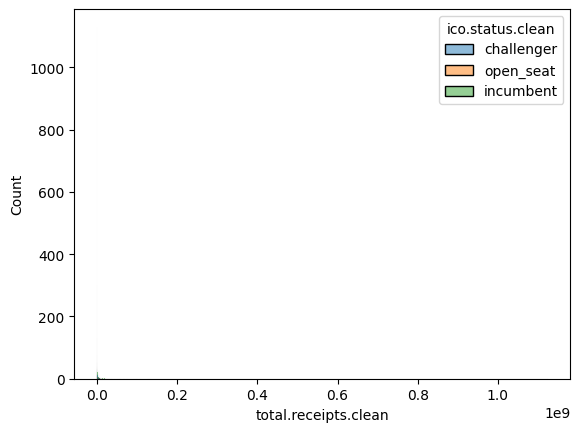

In [ ]:
sns.histplot(                 # Call Seaborn's histogram function
    data=df_bonica,           # Use the DataFrame 'df_bonica' as the source of the data
    x='total.receipts.clean', # Plot the variable 'total.receipts.clean' on the x-axis
    hue='ico.status.clean'    # Color (differentiate) the bars by 'ico.status.clean' groups
)

Right now, the plot is pretty hard to read. Let’s improve the viz.

* Expressing `total.receipts.clean` in **millions of dollars** (so the numbers are easier to interpret).
* Choosing a more appropriate number of **bins** to balance detail and clarity.
* Excluding the **long tail** of extreme values in `total.receipts.clean` that distort the visualization.
* Use `element='step'` argument to outline the bars instead of fill them. This makes them easier to see if they overlap.
* Add clear labels to the x-axis and y-axis, and include a descriptive title so the plot is easy to interpret.



In [ ]:
# total.receipts in millions
df_bonica["total.receipts.clean.m"] = df_bonica["total.receipts.clean"]/1000000

In [ ]:
# get the value + 2sd to visualize about 95% of the data IF normally distributed.
np.mean(df_bonica["total.receipts.clean.m"]) + 2*np.std(df_bonica["total.receipts.clean.m"])

np.float64(50.452246624392274)

In [ ]:
df_bonica_subset = df_bonica.query("`total.receipts.clean.m` < 50.45")

[Text(0.5, 0, 'Total receipts (million $)'),
 Text(0, 0.5, 'Count'),
 Text(0.5, 1.0, 'Receipts by incumbency status')]

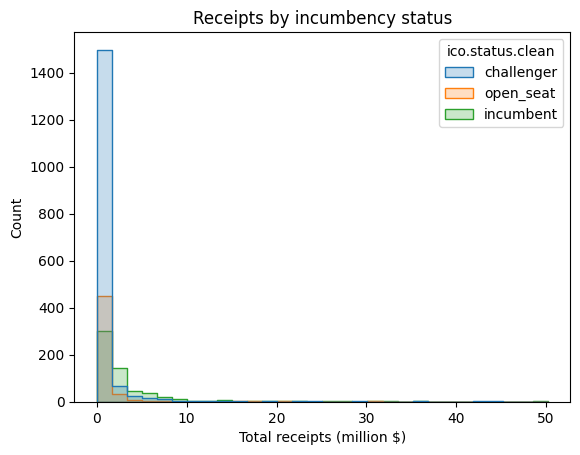

In [ ]:
sns_hist = sns.histplot(data=df_bonica_subset,
                        x='total.receipts.clean.m',
                        hue='ico.status.clean',
                        bins=30,
                        element='step')

sns_hist.set(xlabel='Total receipts (million $)',
             ylabel='Count',
             title='Receipts by incumbency status')

**Bins:**  When you make a histogram, you’re essentially chopping the range of your variable (here, total.receipts.clean) into intervals (the bins). Each bin covers a slice of values (for example, 0–1 million, 1–2 million, etc.), and the height of the bar shows how many observations fall into that slice.

- More bins → narrower intervals: more detail, but the plot can look noisy.
- Fewer bins → wider intervals: smoother plot, but you lose details.


# Congratulations!

You are done with the coding session. Questions or suggestions? Email Alberto at alberto.stefanelli@yale.edu

In [ ]:
# Install requirements
!apt-get -qq update
!apt-get install -y pandoc texlive-xetex texlive-fonts-recommended texlive-plain-generic

from google.colab import drive, files

# Mount Google Drive
drive.mount('/content/drive')

# Ask for the notebook name
notebook_name = input(
    "Enter your notebook’s exact file name,\n"
    "exactly as shown in the top-left corner of the Colab page (next to the two yellow circle icons): "
)

# Build paths
input_path = f"/content/drive/MyDrive/Colab Notebooks/{notebook_name}"
output_path = input_path.replace(".ipynb", ".pdf")

# Convert to PDF
!jupyter nbconvert --to pdf "{input_path}"

# Download the PDF
files.download(output_path)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-bin

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>